In [2]:
%matplotlib inline

In [3]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

### Loading the data

In [4]:
df = pd.read_csv("music_streaming_habits_2026.csv")

print("Rows:", len(df))
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Age range:", df["age"].min(), "to", df["age"].max())

Rows: 4000
Missing values: 0
Duplicate rows: 0
Age range: 13 to 57


### Grouping the Ages into Bands

In [6]:
def age_band(age):
    if age <= 17:
        return "13-17"
    elif age <= 24:
        return "18-24"
    elif age <= 34:
        return "25-34"
    elif age <= 44:
        return "35-44"
    else:
        return "45+"

df["age_band"] = df["age"].apply(age_band)
band_order = ["13-17", "18-24", "25-34", "35-44", "45+"]
print(df["age_band"].value_counts()[band_order].to_string())

age_band
13-17     539
18-24     876
25-34    1692
35-44     785
45+       108


### Building the Graph

In [7]:
g = nx.Graph()

for index, row in df.iterrows():
    band = "age " + row["age_band"]
    genre = row["top_genre"]

    g.add_node(band, kind="age")
    g.add_node(genre, kind="genre")

    # Get the current weight, if it exists
    current_weight = g.get_edge_data(band, genre, default={"weight": 0})["weight"]
    g.add_edge(band, genre, weight=current_weight + 1)

print("Nodes:", g.number_of_nodes(), "Edges:", g.number_of_edges())

# Check: total edge weight should equal the number of listeners
print("Total edge weight:", sum(d["weight"] for u, v, d in g.edges(data=True)), "listeners:", len(df))

Nodes: 17 Edges: 60
Total edge weight: 4000 listeners: 4000


### Degree of Centrality for Genre

In [8]:
print("Plain degree centrality of Pop:", nx.degree_centrality(g)["Pop"])
print("Plain degree centrality of Jazz:", nx.degree_centrality(g)["Jazz"])
print()

weighted_degree = dict(g.degree(weight="weight"))
genres = [n for n in g.nodes if g.nodes[n]["kind"] == "genre"]

print("Top Genres through degree centrality")
for node in sorted(genres, key=weighted_degree.get, reverse=True):
    percent_of_listeners = weighted_degree[node] / len(df) * 100
    print(node, weighted_degree[node], str(round(percent_of_listeners, 1)) + "%")

Plain degree centrality of Pop: 0.3125
Plain degree centrality of Jazz: 0.3125

Top Genres through degree centrality
Pop 721 18.0%
Hip-Hop 605 15.1%
Rock 472 11.8%
EDM 382 9.6%
R&B 341 8.5%
Indie 327 8.2%
K-Pop 278 7.0%
Afrobeats 210 5.2%
Lo-fi 201 5.0%
Classical 166 4.2%
Country 165 4.1%
Jazz 132 3.3%


### Degree of Centrality for Artists

In [9]:
g_artist = nx.Graph()

for index, row in df.iterrows():
    band = "age " + row["age_band"]
    artist = row["top_artist"]

    g_artist.add_node(band, kind="age")
    g_artist.add_node(artist, kind="artist")

    current_weight = g_artist.get_edge_data(band, artist, default={"weight": 0})["weight"]
    g_artist.add_edge(band, artist, weight=current_weight + 1)

artist_degree = dict(g_artist.degree(weight="weight"))
artists = [n for n in g_artist.nodes if g_artist.nodes[n]["kind"] == "artist"]

print("Top Artists through degree centrality")
for node in sorted(artists, key=artist_degree.get, reverse=True):
    percent_of_listeners = artist_degree[node] / len(df) * 100
    print(node, artist_degree[node], str(round(percent_of_listeners, 1)) + "%")

Top Artists through degree centrality
SZA 310 7.8%
Bad Bunny 305 7.6%
The Weeknd 302 7.5%
Dua Lipa 298 7.4%
Taylor Swift 294 7.3%
Travis Scott 293 7.3%
Olivia Rodrigo 290 7.2%
Tyler the Creator 287 7.2%
Drake 285 7.1%
Burna Boy 285 7.1%
Kendrick Lamar 273 6.8%
BTS 268 6.7%
Billie Eilish 266 6.7%
Ariana Grande 244 6.1%


### Top Genre by Age Chart

Most popular genre in each age band:
age_band
13-17    Pop
18-24    Pop
25-34    Pop
35-44    Pop
45+      Pop
dtype: str


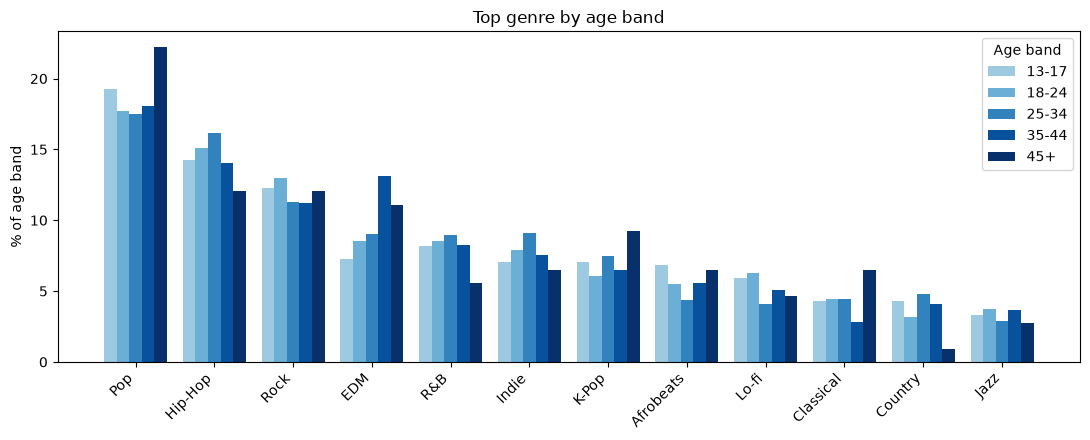

In [10]:
counts = pd.crosstab(df["age_band"], df["top_genre"]).loc[band_order]
percent = counts.div(counts.sum(axis=1), axis=0) * 100

genres_sorted = sorted(genres, key=weighted_degree.get, reverse=True)

print("Most popular genre in each age band:")
print(percent.idxmax(axis=1))

colors = ["#9ecae1", "#6baed6", "#3182bd", "#08519c", "#08306b"]
bar_width = 0.16
x = np.arange(len(genres_sorted))

plt.figure(figsize=(11, 4.5))
for i, b in enumerate(band_order):
    plt.bar(x + i * bar_width, percent.loc[b, genres_sorted], width=bar_width, label=b, color=colors[i])
plt.xticks(x + 2 * bar_width, genres_sorted, rotation=45, ha="right")
plt.ylabel("% of age band")
plt.title("Top genre by age band")
plt.legend(title="Age band")
plt.tight_layout()
plt.savefig("fig1_genre_by_age.png", dpi=150)
plt.show()

### Top Artist by Age Chart

Most popular artist in each age band:
13-17 Taylor Swift 8.5%, Bad Bunny 8.3%, Olivia Rodrigo 8.3%
18-24 Bad Bunny 8.4%, Travis Scott 8.2%, The Weeknd 8.0%
25-34 SZA 8.0%, Dua Lipa 7.6%, Bad Bunny 7.6%
35-44 Dua Lipa 8.8%, The Weeknd 8.7%, Drake 8.4%
45+ Travis Scott 13.0%, Burna Boy 10.2%, Dua Lipa 8.3%


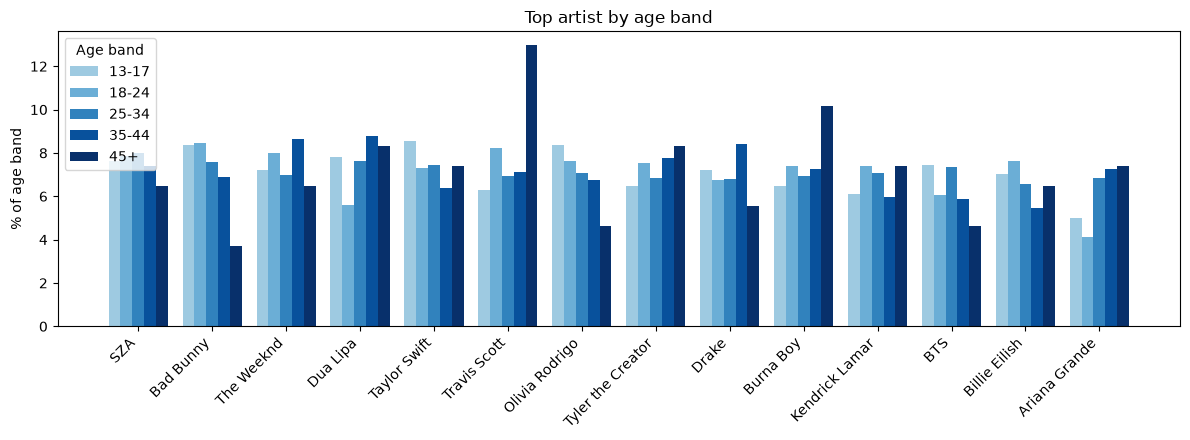

In [11]:
artist_counts = pd.crosstab(df["age_band"], df["top_artist"]).loc[band_order]
artist_percent = artist_counts.div(artist_counts.sum(axis=1), axis=0) * 100

artists_sorted = sorted(artists, key=artist_degree.get, reverse=True)

print("Most popular artist in each age band:")
for b in band_order:
    top = artist_percent.loc[b].sort_values(ascending=False).head(3)
    print(b, ", ".join(name + " " + str(round(pct, 1)) + "%" for name, pct in top.items()))

x = np.arange(len(artists_sorted))

plt.figure(figsize=(12, 4.5))
for i, b in enumerate(band_order):
    plt.bar(x + i * bar_width, artist_percent.loc[b, artists_sorted], width=bar_width, label=b, color=colors[i])
plt.xticks(x + 2 * bar_width, artists_sorted, rotation=45, ha="right")
plt.ylabel("% of age band")
plt.title("Top artist by age band")
plt.legend(title="Age band", loc="upper left")
plt.tight_layout()
plt.savefig("fig2_artist_by_age.png", dpi=150)
plt.show()